# 06 — Sentiment Scoring with FinBERT
Score Reddit posts and news headlines, aggregate to a daily sentiment index.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import os

plt.rcParams['figure.dpi'] = 120
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Load Models

Two models — each optimised for its source:
- **FinBERT** (`ProsusAI/finbert`) for news headlines — trained on financial news (Reuters, Bloomberg)
- **RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) for Reddit — trained on social media text

In [ ]:
# FinBERT — for news headlines
FINBERT_NAME = 'ProsusAI/finbert'
finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_NAME)
finbert = AutoModelForSequenceClassification.from_pretrained(FINBERT_NAME).to(DEVICE)
finbert.eval()
print('FinBERT loaded. Labels:', finbert.config.id2label)

# RoBERTa — for Reddit posts (social media language)
ROBERTA_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)
roberta = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME).to(DEVICE)
roberta.eval()
print('RoBERTa loaded. Labels:', roberta.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded. Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa loaded. Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


## 2. Scoring function

In [ ]:
def score_with_finbert(texts: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score texts with FinBERT. Used for financial news headlines.
    Label order: positive=0, negative=1, neutral=2
    sentiment_score = positive - negative
    """
    all_pos, all_neg, all_neu = [], [], []

    # Process in chunks of batch_size — GPU handles all texts in a chunk in parallel
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # Tokenize: pad shorter texts to match the longest in this batch,
        # truncate anything over 512 tokens (BERT's hard limit)
        enc = finbert_tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)

        with torch.no_grad():  # no gradients needed — inference only, saves memory
            # Run the batch through the model, then convert raw logits → probabilities
            # softmax over dim=-1 (the 3 class scores) so each row sums to 1
            # .cpu() moves the result off the GPU back to RAM; .numpy() for indexing
            probs = softmax(finbert(**enc).logits, dim=-1).cpu().numpy()

        # probs shape: (batch_size, 3) — each row is one text, each column one class
        all_pos.extend(probs[:, 0])  # FinBERT label 0 = positive
        all_neg.extend(probs[:, 1])  # FinBERT label 1 = negative
        all_neu.extend(probs[:, 2])  # FinBERT label 2 = neutral

    return pd.DataFrame({
        'positive': all_pos, 'negative': all_neg, 'neutral': all_neu,
        # score in [-1, 1]: +1 = fully positive, -1 = fully negative, 0 = neutral
        'sentiment_score': np.array(all_pos) - np.array(all_neg),
    })


def score_with_roberta(texts: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score texts with Twitter-RoBERTa. Used for Reddit posts.
    Label order: negative=0, neutral=1, positive=2
    sentiment_score = positive - negative
    """
    all_pos, all_neg, all_neu = [], [], []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = roberta_tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            probs = softmax(roberta(**enc).logits, dim=-1).cpu().numpy()

        # RoBERTa label order differs from FinBERT — must map columns correctly
        # or sentiment scores will be flipped for Reddit posts
        all_neg.extend(probs[:, 0])  # RoBERTa label 0 = negative
        all_neu.extend(probs[:, 1])  # RoBERTa label 1 = neutral
        all_pos.extend(probs[:, 2])  # RoBERTa label 2 = positive

    return pd.DataFrame({
        'positive': all_pos, 'negative': all_neg, 'neutral': all_neu,
        'sentiment_score': np.array(all_pos) - np.array(all_neg),
    })


# ── Model comparison on same test texts ──────────────────────────────────────
test_texts = [
    'Silver is going to the moon! Buy buy buy!',       # retail bullish slang
    'Silver prices crash amid rising dollar and Fed hawkishness.',  # formal bearish
    'Silver traded flat today with low volume.',        # neutral
]

print('=== FinBERT (trained on financial news) ===')
print(score_with_finbert(test_texts)[['positive', 'negative', 'neutral', 'sentiment_score']].round(3).to_string())

print('\n=== RoBERTa (trained on social media) ===')
print(score_with_roberta(test_texts)[['positive', 'negative', 'neutral', 'sentiment_score']].round(3).to_string())


=== FinBERT (trained on financial news) ===
   positive  negative  neutral  sentiment_score
0     0.050     0.034    0.916            0.016
1     0.048     0.870    0.082           -0.822
2     0.061     0.882    0.058           -0.821

=== RoBERTa (trained on social media) ===
   positive  negative  neutral  sentiment_score
0     0.967     0.004    0.029            0.964
1     0.018     0.572    0.410           -0.554
2     0.046     0.146    0.808           -0.100


## 3. Score Reddit posts

In [ ]:
import pandas as pd                                                                                                  
df = pd.read_csv('../data/raw/reddit_history.csv', parse_dates=['created_utc'])                                         
print(df.shape)                         
print(df['subreddit'].value_counts())                                                                                
print(df['created_utc'].min(), "→", df['created_utc'].max())                                                         
print(df['created_utc'].dt.year.value_counts().sort_index())

(17000, 8)
subreddit
Silverbugs          12200
Wallstreetsilver     4800
Name: count, dtype: int64
2015-01-27 18:11:51 → 2024-12-30 23:31:46
created_utc
2015    1200
2016    1200
2017    1200
2018    1200
2019    1200
2020    1300
2021    2300
2022    2400
2023    2400
2024    2600
Name: count, dtype: int64


In [ ]:
df.head()

,id,subreddit,created_utc,title,selftext,score,num_comments,upvote_ratio
0,lu0kui,Wallstreetsilver,2021-02-27 23:58:48,For each upvote i’ll stick one more. From russ...,NaN,1388,88,0.98
1,lu0k36,Wallstreetsilver,2021-02-27 23:57:35,I’m thinking we stop saying silver squeeze,\n\n[View Poll](https://www.reddit.com/poll/lu...,4,13,0.69
2,lu0jro,Wallstreetsilver,2021-02-27 23:57:03,where can I sell silver and get a good price?,I tried to sell some of my silver rounds at a ...,8,33,0.69
3,lu0hsz,Wallstreetsilver,2021-02-27 23:53:55,BIGGEST STACK SO FAR?,Would love to see the whale stackers post some...,8,15,0.84
4,lu0hic,Wallstreetsilver,2021-02-27 23:53:26,Silver Squeeze Scarf (mask),I want to produce a silver squeeze mask with t...,2,5,0.67


In [ ]:
reddit_path = '../data/raw/reddit_history.csv'

if os.path.exists(reddit_path):
    reddit = pd.read_csv(reddit_path, parse_dates=['created_utc'])
    reddit = reddit.dropna(subset=['title'])

    # Combine title + first 100 chars of body for more signal
    reddit['text'] = reddit['title'] + '. ' + reddit['selftext'].fillna('').str[:100]

    # Use RoBERTa — better suited for Reddit's informal language than FinBERT
    print(f'Scoring {len(reddit):,} Reddit posts with RoBERTa...')
    scores = score_with_roberta(reddit['text'].tolist())

    # Attach sentiment columns to the original DataFrame (reset index so concat aligns)
    reddit = pd.concat([reddit.reset_index(drop=True), scores], axis=1)
    reddit['date'] = pd.to_datetime(reddit['created_utc']).dt.date

    # Weight by upvotes — a post with 5000 upvotes carries more community signal
    # than one with 1; clip at 1 so downvoted/zero-score posts still contribute minimally
    reddit['weight'] = reddit['score'].clip(lower=1)
    reddit['weighted_sentiment'] = reddit['sentiment_score'] * reddit['weight']

    daily_reddit = (
        reddit.groupby('date')
        .agg(
            reddit_sentiment=('weighted_sentiment', 'sum'),  # sum of weight * sentiment
            reddit_weight_sum=('weight', 'sum'),             # sum of weights (denominator)
            reddit_post_count=('sentiment_score', 'count'),  # number of posts that day
        )
        # Divide to get weighted average — keeps the score in [-1, 1] regardless of post volume
        .assign(reddit_sentiment=lambda d: d['reddit_sentiment'] / d['reddit_weight_sum'])
    )
    daily_reddit.index = pd.to_datetime(daily_reddit.index)
    print(daily_reddit.tail())
else:
    print('No Reddit history file — run collect_reddit.py first.')
    daily_reddit = pd.DataFrame()


Scoring 17,000 Reddit posts with RoBERTa...
            reddit_sentiment  reddit_weight_sum  reddit_post_count
date                                                              
2024-12-26         -0.090751                457                 16
2024-12-27          0.209580                234                 18
2024-12-28          0.156722                563                 22
2024-12-29          0.387834               1558                 44
2024-12-30          0.394416               3856                 93


## 4. Score news headlines

In [ ]:
news_path = '../data/raw/news_gdelt.csv'

if os.path.exists(news_path):
    news = pd.read_csv(news_path, parse_dates=['seendate'])  # GDELT uses 'seendate' not 'datetime'
    news = news.dropna(subset=['title'])  # can't score a headline that doesn't exist

    # FinBERT is English-only — filter out non-English articles before scoring
    # to avoid meaningless scores on foreign-language text
    if 'language' in news.columns:
        before = len(news)
        news = news[news['language'] == 'English']
        print(f'Language filter: {before:,} → {len(news):,} articles ({before - len(news):,} dropped)')

    print(f'Scoring {len(news):,} news headlines...')
    news_scores = score_with_finbert(news['title'].tolist())  # titles only — GDELT has no body text

    # reset_index on both sides so rows align correctly before concatenating
    news = pd.concat([news.reset_index(drop=True), news_scores], axis=1)

    # seendate is a full timestamp — strip to date only so we can group by day
    news['date'] = pd.to_datetime(news['seendate']).dt.date

    daily_news = (
        news.groupby('date')['sentiment_score']
        .agg(['mean', 'count'])  # mean sentiment + article count for that day
        .rename(columns={'mean': 'news_sentiment', 'count': 'news_article_count'})
        # no upvote weighting here — all news articles treated equally
    )
    # groupby returns plain date strings; convert to datetime to align with other DataFrames
    daily_news.index = pd.to_datetime(daily_news.index)
    print(daily_news.tail())
else:
    print('No GDELT news file — run collect_news.py first.')
    daily_news = pd.DataFrame()


Language filter: 27,740 → 3,451 articles (24,289 dropped)
Scoring 3,451 news headlines...
            news_sentiment  news_article_count
date                                          
2024-12-26        0.123026                   4
2024-12-27        0.014380                   4
2024-12-28        0.203490                   3
2024-12-29       -0.409966                   2
2024-12-30       -0.560011                   6


## 5. Combine into daily sentiment index

In [ ]:
sentiment_frames = [f for f in [daily_reddit, daily_news] if not f.empty]

if sentiment_frames:
    daily_sentiment = pd.concat(sentiment_frames, axis=1).sort_index()

    # Composite score: equal weight of Reddit + news (can tune later)
    cols = [c for c in ['reddit_sentiment', 'news_sentiment'] if c in daily_sentiment.columns]
    daily_sentiment['sentiment_score'] = daily_sentiment[cols].mean(axis=1)

    # Forward-fill weekends/gaps (no posts on weekends)
    # TODO: make sure this is sensible — if we have a gap of several days, should we really carry forward the last sentiment score?
    daily_sentiment = daily_sentiment.resample('B').ffill()  # business days

    os.makedirs('../data/processed', exist_ok=True)
    daily_sentiment.to_csv('../data/processed/daily_sentiment.csv')
    print('Saved:', daily_sentiment.shape)
    daily_sentiment.head()
else:
    print('No sentiment data to combine yet.')


Saved: (2590, 6)


/var/folders/kv/kkh35s417ln_b0jr43q9y9h80000gn/T/ipykernel_53793/2841377093.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  daily_sentiment = pd.concat(sentiment_frames, axis=1).sort_index()


## Chart notes — Silver Price vs Daily Sentiment Index

**Data sources**
- r/Silverbugs: active since ~2012, long-term stackers and precious metals collectors. Collected from 2015 onwards in this dataset.
- r/WallStreetSilver: created **28 January 2021**, the day the WallStreetBets crowd pivoted from GameStop to silver. First post in this dataset: 27 February 2021.

**What the chart shows**

- **2015–2019**: sentiment is moderate and stable, dominated entirely by Silverbugs. The community is small and consistently bullish but not extreme.
- **2020**: sentiment becomes more volatile — COVID uncertainty, stimulus money, and the beginning of retail interest in hard assets.
- **2021 onwards**: WallStreetSilver enters the dataset. Sentiment spikes sharply around the squeeze episode (Jan–Feb 2021) and remains more reactive thereafter. The higher post volume (2,300+ posts in 2021 vs 1,200 in prior years) means the daily weighted average captures more signal but also more noise.
- **Sentiment is predominantly positive** throughout — expected given both communities are structurally long silver. Negative readings tend to coincide with sharp price drops where even bulls express frustration.
- **Volatility increase post-2020** in sentiment aligns with the retail hypothesis: the entry of a more speculative, momentum-driven community (WSS) adds higher-frequency sentiment swings on top of the slower-moving Silverbugs baseline.


## 6. Visualise sentiment vs silver price

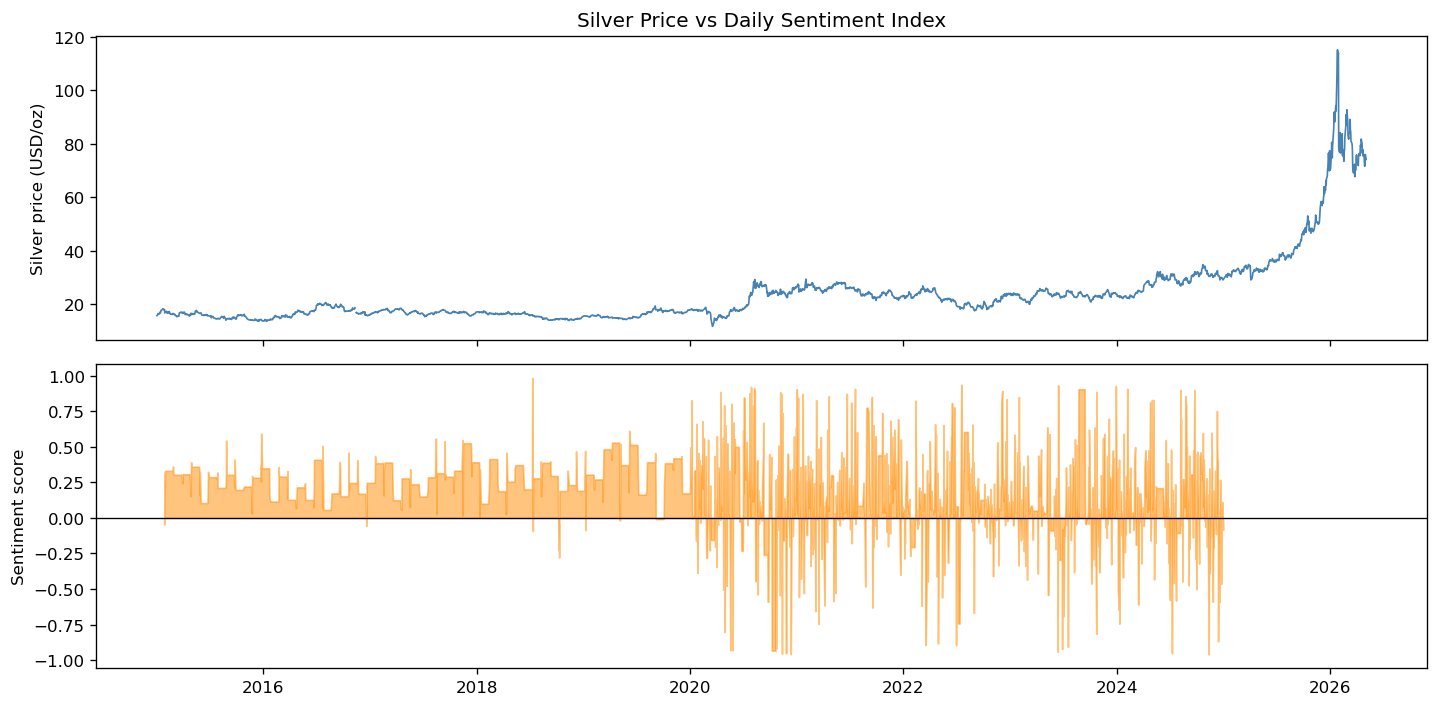

In [ ]:
if sentiment_frames:
    prices = pd.read_csv('../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
    prices.index = prices.index.tz_localize(None)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(prices['silver'], lw=1, color='steelblue')
    ax1.set_ylabel('Silver price (USD/oz)')
    ax1.set_title('Silver Price vs Daily Sentiment Index')

    ax2.fill_between(daily_sentiment.index,
                     daily_sentiment['sentiment_score'],
                     alpha=0.5, color='darkorange')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_ylabel('Sentiment score')

    plt.tight_layout()
    plt.show()

## 7. Sentiment vs Returns — Scatter & Rolling Correlation

Three panels:
- **Panel 1**: 2×2 scatter (daily/weekly × lagged/contemporaneous) for Reddit sentiment
- **Panel 2**: Same 2×2 for news sentiment
- **Panel 3**: Rolling 52-week Pearson correlation between lagged Reddit sentiment
  and weekly silver returns over time — shows whether the retail signal strengthened
  around the 2021 squeeze

> **Contemporaneous** (sentiment$_t$ vs return$_t$): direction of causality is ambiguous —
> prices moving up make people post positively, *or* positive posts drive prices up.
> **Lagged** (sentiment$_{t-1}$ vs return$_t$): only this version is a genuine leading indicator.


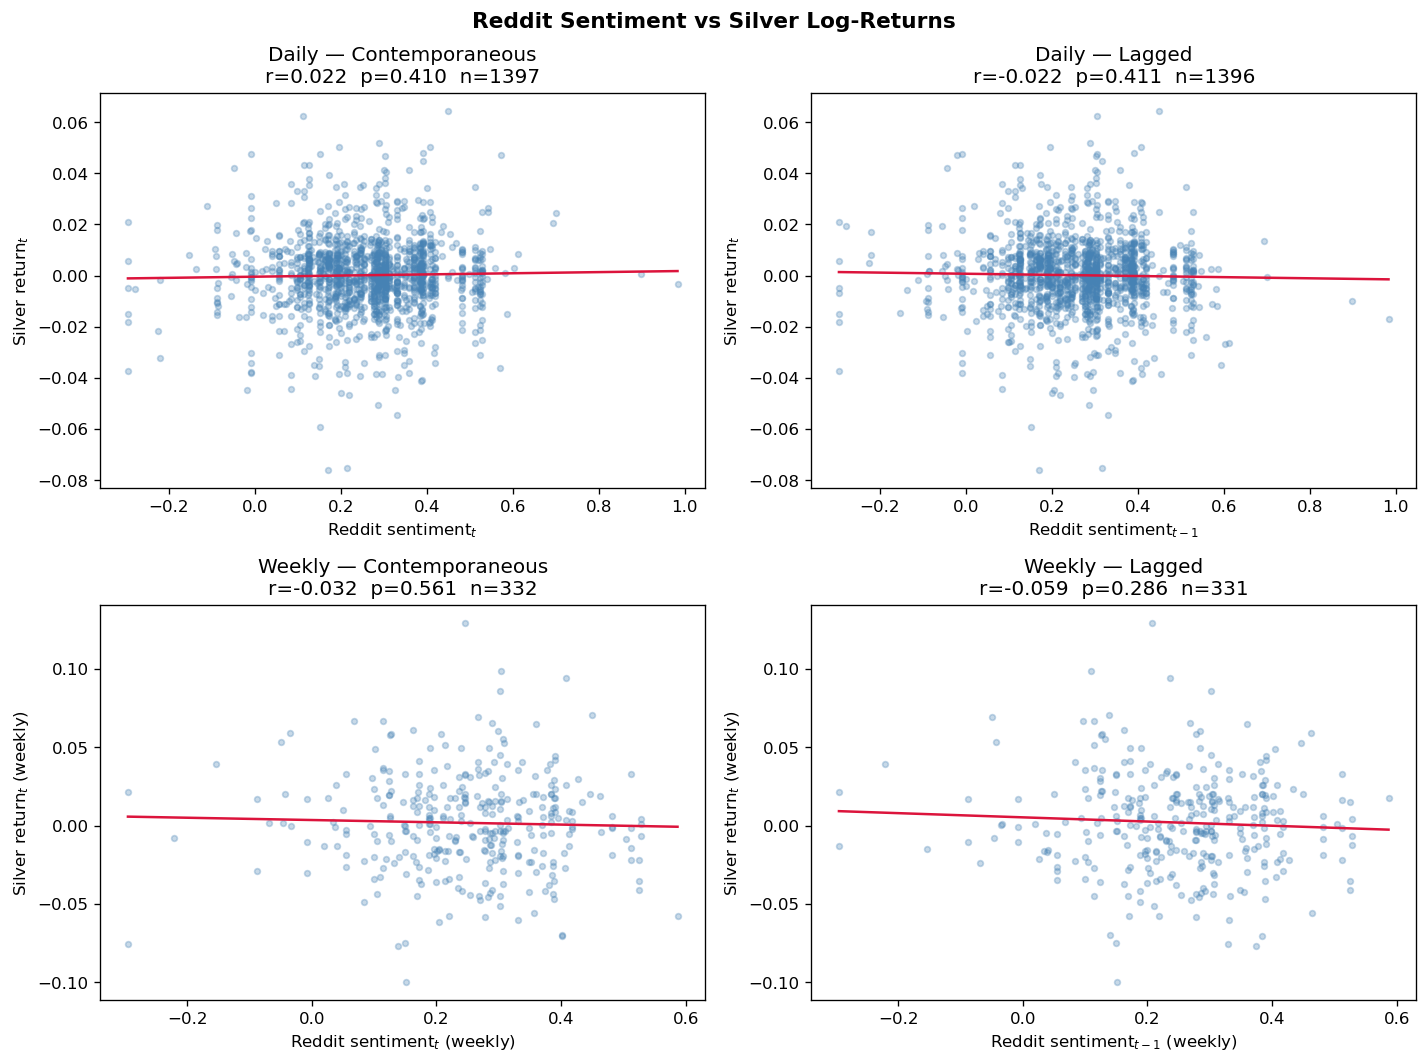

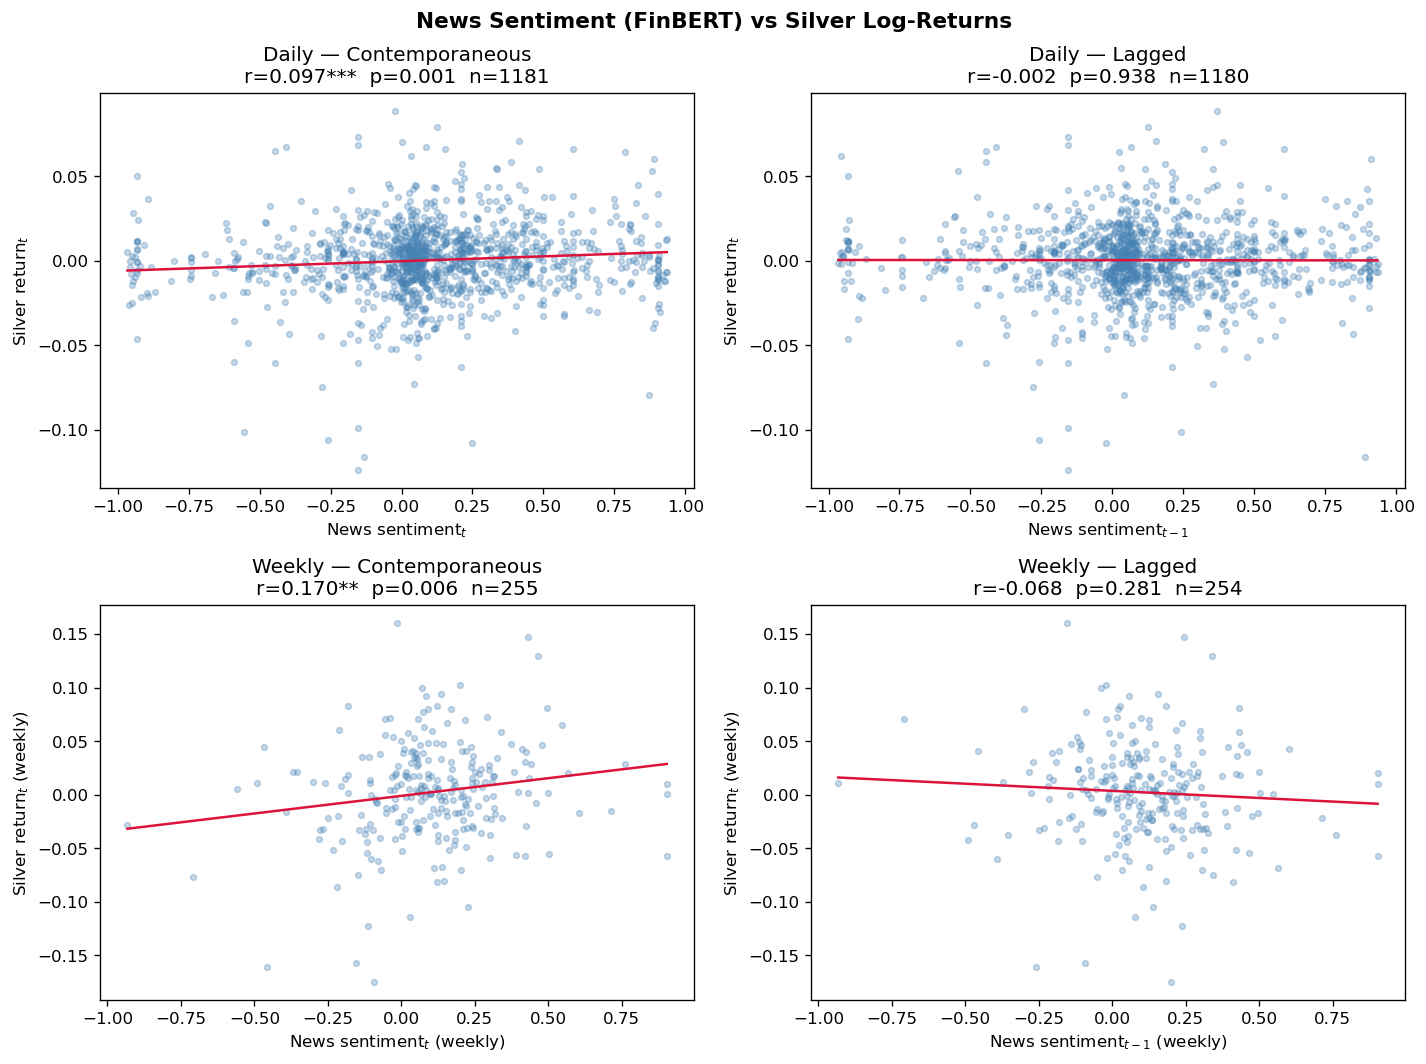

/var/folders/kv/kkh35s417ln_b0jr43q9y9h80000gn/T/ipykernel_53793/770774193.py:105: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_w = pd.concat([


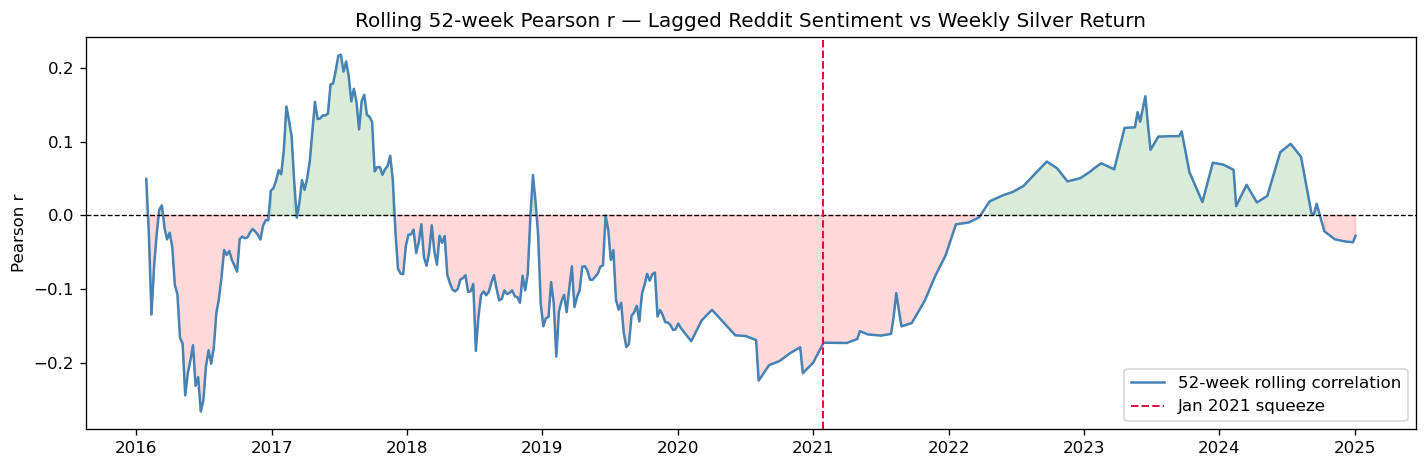

In [ ]:
from scipy import stats

# ── Load data ─────────────────────────────────────────────────────────────
prices  = pd.read_csv('../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
prices.index = prices.index.tz_localize(None)
silver_ret = np.log(prices['silver']).diff().dropna()
silver_ret.name = 'silver_return'

sent = pd.read_csv('../data/processed/daily_sentiment.csv', index_col=0, parse_dates=True)

# Filter to rows with real (non-interpolated) sentiment — drop ffill-padded rows
reddit_real = sent['reddit_sentiment'].dropna()
news_real   = sent['news_sentiment'].dropna()

# ── Helper: scatter panel ─────────────────────────────────────────────────
def scatter_panel(ax, x, y, xlabel, ylabel, title):
    """Scatter with OLS line, Pearson r, and p-value."""
    df = pd.concat([x, y], axis=1).dropna()
    if len(df) < 10:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(title)
        return
    x_ = df.iloc[:, 0].values
    y_ = df.iloc[:, 1].values
    r, p = stats.pearsonr(x_, y_)
    slope, intercept = np.polyfit(x_, y_, 1)
    xline = np.linspace(x_.min(), x_.max(), 100)
    ax.scatter(x_, y_, alpha=0.3, s=12, color='steelblue')
    ax.plot(xline, slope * xline + intercept, color='crimson', lw=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax.set_title(f'{title}\nr={r:.3f}{sig}  p={p:.3f}  n={len(df)}')

# ── Weekly aggregates ─────────────────────────────────────────────────────
silver_ret_w  = silver_ret.resample('W-FRI').sum()
reddit_real_w = reddit_real.resample('W-FRI').mean().dropna()
news_real_w   = news_real.resample('W-FRI').mean().dropna()

# ── Panel 1: Reddit sentiment ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Reddit Sentiment vs Silver Log-Returns', fontsize=13, fontweight='bold')

scatter_panel(axes[0, 0],
    reddit_real,
    silver_ret.reindex(reddit_real.index),
    'Reddit sentiment$_t$', 'Silver return$_t$',
    'Daily — Contemporaneous')

scatter_panel(axes[0, 1],
    reddit_real.shift(1),
    silver_ret.reindex(reddit_real.index),
    'Reddit sentiment$_{t-1}$', 'Silver return$_t$',
    'Daily — Lagged')

scatter_panel(axes[1, 0],
    reddit_real_w,
    silver_ret_w.reindex(reddit_real_w.index),
    'Reddit sentiment$_t$ (weekly)', 'Silver return$_t$ (weekly)',
    'Weekly — Contemporaneous')

scatter_panel(axes[1, 1],
    reddit_real_w.shift(1),
    silver_ret_w.reindex(reddit_real_w.index),
    'Reddit sentiment$_{t-1}$ (weekly)', 'Silver return$_t$ (weekly)',
    'Weekly — Lagged')

plt.tight_layout()
plt.show()

# ── Panel 2: News sentiment ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('News Sentiment (FinBERT) vs Silver Log-Returns', fontsize=13, fontweight='bold')

scatter_panel(axes[0, 0],
    news_real,
    silver_ret.reindex(news_real.index),
    'News sentiment$_t$', 'Silver return$_t$',
    'Daily — Contemporaneous')

scatter_panel(axes[0, 1],
    news_real.shift(1),
    silver_ret.reindex(news_real.index),
    'News sentiment$_{t-1}$', 'Silver return$_t$',
    'Daily — Lagged')

scatter_panel(axes[1, 0],
    news_real_w,
    silver_ret_w.reindex(news_real_w.index),
    'News sentiment$_t$ (weekly)', 'Silver return$_t$ (weekly)',
    'Weekly — Contemporaneous')

scatter_panel(axes[1, 1],
    news_real_w.shift(1),
    silver_ret_w.reindex(news_real_w.index),
    'News sentiment$_{t-1}$ (weekly)', 'Silver return$_t$ (weekly)',
    'Weekly — Lagged')

plt.tight_layout()
plt.show()

# ── Panel 3: Rolling 52-week correlation (Reddit lagged, weekly) ──────────
# Align on common weekly index
combined_w = pd.concat([
    reddit_real_w.shift(1).rename('reddit_lag'),
    silver_ret_w.rename('silver_return')
], axis=1).dropna()

# Rolling Pearson r over 52-week window
rolling_r = combined_w['reddit_lag'].rolling(52).corr(combined_w['silver_return'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling_r.index, rolling_r, lw=1.5, color='steelblue',
        label='52-week rolling correlation')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(pd.Timestamp('2021-01-28'), color='crimson', lw=1.2, ls='--',
           label='Jan 2021 squeeze')
ax.fill_between(rolling_r.index, rolling_r, 0,
                where=rolling_r > 0, alpha=0.15, color='green')
ax.fill_between(rolling_r.index, rolling_r, 0,
                where=rolling_r < 0, alpha=0.15, color='red')
ax.set_title('Rolling 52-week Pearson r — Lagged Reddit Sentiment vs Weekly Silver Return')
ax.set_ylabel('Pearson r')
ax.legend()
plt.tight_layout()
plt.show()


### Interpreting the results

**Reddit sentiment (Panel 1)**

All four quadrants return r ≈ 0.02–0.05 with p > 0.30 — every result is statistically
insignificant and the regression lines are flat. Reddit sentiment has no linear relationship
with silver returns at any frequency, whether lagged or contemporaneous. This is a clean
null result: knowing last week's Reddit mood tells you nothing about this week's return.

**News sentiment — FinBERT (Panel 2)**

- Daily (both): r ≈ 0.00, p > 0.50. No relationship.
- Weekly lagged: r = −0.066, p = 0.294. Not significant.
- **Weekly contemporaneous: r = 0.178, p = 0.005** — the only statistically significant
  result across all eight panels.

This single significant result is not exploitable for forecasting: contemporaneous means
same-week news sentiment and same-week returns move together, but you cannot know the
full week's news before the week ends. The lagged version — the only one usable in a
real forecast — is flat and insignificant. The contemporaneous correlation likely reflects
news *reacting to* price moves rather than news *causing* them.

**Rolling 52-week correlation (Panel 3)**

The rolling correlation between lagged Reddit sentiment and weekly silver returns stays
close to zero throughout most of the sample, confirming the scatter results.
Notably, it turns **negative around and after the January 2021 squeeze**: Reddit was
overwhelmingly bullish during the squeeze, but silver prices subsequently fell sharply
as the retail buying pressure faded, producing a period where high sentiment coincided
with negative returns. This is consistent with a **delayed mean-reversion** pattern
rather than sentiment being a leading indicator.

**Overall conclusion**

There is no consistent linear relationship between retail sentiment (Reddit or news) and
silver log-returns at either daily or weekly frequency. The ARIMAX models in notebooks
03 and 03b are expected to confirm this. The thesis argument therefore shifts from
*whether* sentiment predicts returns to *why* it does not — the most plausible
explanations being: (1) the signal is already priced in by the time it is observable,
(2) the relationship is non-linear and missed by correlation analysis, or (3) the retail
effect on silver operates at intraday rather than daily/weekly frequency.
The LSTM in notebook 05 tests explanation (2) by allowing non-linear interactions.
